# Network Traffic Routing with QAOA

**Hackathon challenge (AT&T): route traffic demands through a capacitated network, minimizing latency and congestion.**

Hybrid pipeline:

1. *Classical*: enumerate a small set of candidate paths per demand (K-shortest paths) — **assumed given here**.
2. **Quantum (this notebook)**: encode "pick one path per demand" as a QUBO and solve it with QAOA on Classiq.
3. *Classical*: decode the sampled bitstrings, validate capacity, and report KPIs.

The congestion objective follows the canonical traffic-engineering cost of
**Fortz & Thorup, "Internet Traffic Engineering by Optimizing OSPF Weights", IEEE INFOCOM 2000** —
the AT&T Labs paper on the AT&T WorldNet backbone. Our per-demand explicit-path selection is the
restricted *optimal general routing* (MPLS-style) side of their comparison.

QAOA: Farhi, Goldstone & Gutmann, [arXiv:1411.4028](https://arxiv.org/abs/1411.4028). Classiq idioms follow the official
`classiq-library` telecom notebook (`applications/telecom/network_traffic_optimization`).

## Setup

Requires the shared venv (`../../.venv`, Python 3.11, `classiq==1.29.0`). Synthesis and execution talk to the
Classiq cloud — if a `ClassiqExpiredTokenError` appears, uncomment and run the `authenticate()` cell (browser flow).

In [ ]:
import dataclasses
import itertools

import matplotlib.pyplot as plt
import networkx as nx
import pandas as pd

from routing_qaoa import (
    CONGESTION_THRESHOLD_PHI_STAR,
    CandidatePath,
    Demand,
    Link,
    QuboWeights,
    RoutingInstance,
    best_feasible_solution,
    brute_force_feasible,
    compute_coefficients,
    decode_bitstring,
    feasible_probability,
    plot_energy_landscape,
    plot_fortz_thorup_curve,
    plot_link_utilization,
    plot_network,
    plot_routing,
    plot_sampled_cost_distribution,
    plot_solution_comparison,
    to_networkx,
    top_solutions,
)
from routing_qaoa.qaoa import QaoaConfig, build_qaoa_main, run_qaoa
from routing_qaoa.qubo import build_cost_function

In [2]:
# import classiq
# classiq.authenticate()  # run once per machine (opens a browser)

## The QUBO / cost Hamiltonian

One binary decision variable per candidate path: $x_{k,p} \in \{0,1\}$ — demand $k$ routes on its
candidate path $p$. Qubits are indexed flat, $i = \mathrm{offset}_k + p$, so demands may have different
numbers of candidate paths; the total qubit count is $N = \sum_k |P_k|$.

$$H \;=\; \lambda_{\text{1hot}} \underbrace{\sum_k \Big(\sum_p x_{k,p} - 1\Big)^2}_{\text{one path per demand}}
\;+\; \underbrace{\sum_{k,p} \tilde L_{k,p}\, x_{k,p}}_{\text{latency}}
\;+\; \lambda_{\text{cong}} \underbrace{\frac{1}{m}\sum_e g(u_e)}_{\text{congestion}}
\;+\; \lambda_{\text{switch}} \underbrace{\sum_{k}\sum_{p \neq p_{\text{cur}}(k)} x_{k,p}}_{\text{route changes (optional)}}$$

- **Latency**: $\tilde L_{k,p} \propto \pi_k \cdot b_k \cdot \mathrm{lat}(p)$, normalized so the feasible-space spread is
  exactly `cost_scale` (keeps $e^{-i\gamma H}$ away from phase wrap-around, following the Classiq telecom notebook).
- **Priority** $\pi_k$ (per demand, `Demand.priority`): a service-class coefficient on demand $k$'s latency term —
  $\pi_k = 1$ is neutral, $\pi_k > 1$ buys demand $k$ a stronger pull toward its low-latency paths when demands
  contend for the same link. Because latency is spread-normalized, a *global* rescale $\pi_k \to c\,\pi_k$ cancels:
  only the **ratios** between demands matter. Raising one $\pi_k$ therefore reallocates a fixed latency budget toward
  demand $k$ and weakens the others' latency pull relative to congestion — the intended service-class semantics.
- **Congestion** (*soft* capacity — no slack qubits): link utilization $u_e = \sum_{(k,p)\,:\,e \in p} \frac{b_k}{c_e}\, x_{k,p}$
  is linear in $x$, so any quadratic $g(u_e)$ stays QUBO. Note $\pi_k$ is deliberately **absent** here — $u_e$ is
  physical link load, and the Fortz–Thorup fit below is calibrated against real utilizations. Two profiles:
  - `"quadratic"`: $g(u) = u^2$;
  - `"fortz-thorup-fit"`: $g(u) = \alpha u + \beta u^2$, a least-squares fit of the exact Fortz–Thorup
    piecewise-linear link cost $\Phi_e$ (slopes $1,3,10,70,500,5000$ at utilizations
    $\tfrac13, \tfrac23, \tfrac9{10}, 1, \tfrac{11}{10}$) — the hockey-stick tail calibrates $\beta \approx 16$,
    i.e. ~16$\times$ the default congestion pressure.
- **Hard feasibility is checked classically at decode time**; KPIs report the *exact* piecewise $\Phi$ and the paper's
  normalized $\Phi^\* = \Phi / \Phi_{\text{Uncap}}$, where $\Phi_{\text{Uncap}} = \sum_k b_k \cdot \mathrm{hopdist}(s_k, t_k)$.
  $\Phi^\* = 1$ is ideal; $\Phi^\* \ge \tfrac{32}{3} \approx 10.67$ means the network is congested. These are physical
  network quantities, so $\pi_k$ does not enter them either.

## Toy instance

6 routers, 9 directed links (capacity, latency), 3 demands. Candidate paths come from `networkx.shortest_simple_paths`
(K=3 by latency) — **a stand-in for pipeline step 2**. The instance is adversarial on purpose: every demand's
latency-shortest path funnels through the thin link $B\!\to\!D$ ($c=5$), so pure latency optimization overloads it.

Demand `d1` carries **priority $\pi_1 = 3$** (a premium service class); `d2` and `d3` stay neutral at $\pi = 1$.
$B\!\to\!D$ cannot carry both `d1` and `d3`, so the two contend for it — and the priority decides who wins.

In [ ]:
LINKS = (
    Link("A", "B", capacity=10, latency=1),
    Link("B", "D", capacity=5, latency=1),
    Link("A", "C", capacity=10, latency=2),
    Link("C", "D", capacity=10, latency=2),
    Link("B", "C", capacity=5, latency=1),
    Link("D", "E", capacity=10, latency=1),
    Link("D", "F", capacity=5, latency=2),
    Link("E", "F", capacity=10, latency=1),
    Link("C", "E", capacity=10, latency=3),
)
DEMANDS = (
    Demand("d1", source="A", target="F", bandwidth=4, priority=3.0),  # premium class
    Demand("d2", source="A", target="E", bandwidth=3),
    Demand("d3", source="B", target="F", bandwidth=3),
)
K_PATHS = 3  # candidate paths per demand (pipeline step 2 stand-in)

graph = to_networkx(LINKS)


def k_shortest_candidate_paths(demand: Demand, k: int) -> tuple[CandidatePath, ...]:
    node_paths = nx.shortest_simple_paths(graph, demand.source, demand.target, weight="latency")
    return tuple(
        CandidatePath(tuple(zip(nodes, nodes[1:]))) for nodes in itertools.islice(node_paths, k)
    )


instance = RoutingInstance(
    links=LINKS,
    demands=DEMANDS,
    candidate_paths={d.name: k_shortest_candidate_paths(d, K_PATHS) for d in DEMANDS},
)

index_table = pd.DataFrame(
    {
        "qubit": i,
        "demand": instance.demands[k].name,
        "path": " → ".join([path.links[0][0]] + [v for _, v in path.links]),
        "latency": instance.path_latency(k, p),
        "bandwidth": instance.demands[k].bandwidth,
        "priority": instance.demands[k].priority,
    }
    for i in range(instance.num_qubits)
    for k, p in [instance.demand_path_at(i)]
    for path in [instance.paths_of(k)[p]]
)
print(f"N = {instance.num_qubits} qubits (one per candidate path)")
index_table

In [ ]:
# Fixed layout for the toy topology; omit `pos` to fall back to routing_qaoa.viz.network_layout.
POS = {"A": (0, 0.5), "B": (1, 1), "C": (1, 0), "D": (2, 1), "E": (2, 0), "F": (3, 0.5)}

plot_network(instance, pos=POS)
plt.show()

## Classical reference: the congestion knob

Brute force over all one-hot assignments ($\prod_k |P_k| = 27$ combinations) shows what each congestion setting
considers "optimal". Latency-only routing double-overloads $B\!\to\!D$; the Fortz–Thorup-calibrated profile finds the
capacity-clean routing at the cost of some latency.

In [5]:
WEIGHT_CONFIGS = {
    "latency only (λ_cong = 0)": QuboWeights(lambda_cong=0.0),
    "quadratic, λ_cong = 1 (default)": QuboWeights(),
    "quadratic, λ_cong = 5": QuboWeights(lambda_cong=5.0),
    "Fortz–Thorup fit": QuboWeights(congestion_profile="fortz-thorup-fit", cost_scale=0.1),
}

rows = []
for label, weights in WEIGHT_CONFIGS.items():
    ref = brute_force_feasible(instance, weights)
    sol = decode_bitstring(list(ref.best_bits), instance, compute_coefficients(instance, weights))
    rows.append(
        {
            "weights": label,
            **{f"path[{name}]": p for name, p in ref.best_assignment.items()},
            "max_util": sol.max_utilization,
            "cap_violations": sol.capacity_violations,
            "weighted_latency": sol.weighted_latency,
            "Φ*": round(sol.phi_star, 2),
        }
    )

# the congestion term must change the routing decision — otherwise the demo is trivial
assert (
    brute_force_feasible(instance, QuboWeights()).best_assignment
    != brute_force_feasible(instance, QuboWeights(lambda_cong=0.0)).best_assignment
)
pd.DataFrame(rows)

,weights,path[d1],path[d2],path[d3],max_util,cap_violations,weighted_latency,Φ*
0,latency only (λ_cong = 0),0,0,0,2.0,2,34.0,1276.10
1,"quadratic, λ_cong = 1 (default)",1,0,0,2.0,1,34.0,951.99
2,"quadratic, λ_cong = 5",2,1,1,0.8,0,48.0,2.08
3,Fortz–Thorup fit,2,1,1,0.8,0,48.0,2.08


## Classical reference: the priority knob

The same brute force, now varying $\pi_1$ instead of the congestion profile (weights fixed at the Fortz–Thorup fit).
`d1` ($A\!\to\!F$) and `d3` ($B\!\to\!F$) both want the thin $B\!\to\!D$ link, which cannot carry both — so exactly one
of them gets a low-latency route and the other is pushed onto a detour. At neutral priority `d3` wins it; raising
$\pi_1$ flips the decision, and `d1` takes $B\!\to\!D$ while `d3` detours via $B\!\to\!C\!\to\!D$.

Both routings are capacity-clean, so this is a genuine *preference* change, not a feasibility artifact: $\Phi^\*$ barely
moves while the premium demand's own latency drops from 6 to 4.

In [ ]:
def with_priority(pi_1: float) -> RoutingInstance:
    """The same instance with demand d1's priority set to `pi_1` (others neutral)."""
    demands = (dataclasses.replace(DEMANDS[0], priority=pi_1),) + DEMANDS[1:]
    return RoutingInstance(
        links=LINKS,
        demands=demands,
        candidate_paths={d.name: k_shortest_candidate_paths(d, K_PATHS) for d in demands},
    )


PRIORITY_WEIGHTS = WEIGHT_CONFIGS["Fortz–Thorup fit"]

rows = []
for pi_1 in (1.0, 2.0, 3.0, 5.0):
    inst = with_priority(pi_1)
    ref = brute_force_feasible(inst, PRIORITY_WEIGHTS)
    sol = decode_bitstring(
        list(ref.best_bits), inst, compute_coefficients(inst, PRIORITY_WEIGHTS)
    )
    k_d1 = 0  # d1's own latency: the KPI the premium class is paying for
    rows.append(
        {
            "π(d1)": pi_1,
            **{f"path[{name}]": p for name, p in ref.best_assignment.items()},
            "lat(d1)": inst.path_latency(k_d1, ref.best_assignment["d1"]),
            "max_util": sol.max_utilization,
            "cap_violations": sol.capacity_violations,
            "weighted_latency": sol.weighted_latency,
            "Φ*": round(sol.phi_star, 2),
        }
    )

# priority must change the routing decision — otherwise the demo is trivial
assert (
    brute_force_feasible(with_priority(3.0), PRIORITY_WEIGHTS).best_assignment
    != brute_force_feasible(with_priority(1.0), PRIORITY_WEIGHTS).best_assignment
)
pd.DataFrame(rows)

## What the congestion term buys

The table above is the argument; this is the picture of it. Left: latency-only routing, which sends everything down
the shortest hops and drives $B\!\to\!D$ to **200% of capacity**. Right: the Fortz–Thorup-calibrated objective, which
pays some latency to keep every link inside capacity. Both utilization panels share one color scale, so the same red
means the same overload in both columns.

Below that, the cost function itself. Fortz & Thorup's $\Phi_e$ is piecewise linear with slopes
$1, 3, 10, 70, 500, 5000$ — nearly free below a third of capacity, catastrophic past it. A QUBO can only express a
quadratic, so `congestion_profile="fortz-thorup-fit"` uses the least-squares $\alpha u + \beta u^2$; the fit's
$\beta \approx 16.7$ is what the hockey-stick tail calibrates. Each dot is one link of the chosen routing, sitting
where it lands on the exact curve — all of them comfortably left of the $u = 1$ knee.

In [ ]:
# Both routings are decoded under the SAME coefficients, so their costs are comparable.
PRESENTATION_WEIGHTS = WEIGHT_CONFIGS["Fortz–Thorup fit"]
presentation_coeffs = compute_coefficients(instance, PRESENTATION_WEIGHTS)

comparison = {}
for label, weights in (
    ("latency only (λ_cong = 0)", WEIGHT_CONFIGS["latency only (λ_cong = 0)"]),
    ("Fortz–Thorup congestion-aware", PRESENTATION_WEIGHTS),
):
    ref_bits = brute_force_feasible(instance, weights).best_bits
    sol = decode_bitstring(list(ref_bits), instance, presentation_coeffs)
    comparison[f"{label} — {sol.capacity_violations} links over capacity"] = sol

plot_solution_comparison(instance, comparison, pos=POS)
plt.show()

ft_solution = list(comparison.values())[-1]
plot_fortz_thorup_curve(solution=ft_solution, instance=instance)
plt.show()

## QAOA ansatz

Standard QAOA (Farhi et al. 2014) with the Classiq `phase()` idiom: start in $|+\rangle^{\otimes N}$, then alternate
$p$ layers of the cost phase $e^{-i\gamma_l H}$ — built by `phase(cost(x), γ_l)` directly from the *same Python cost
function* used classically — and the transverse mixer $e^{-i\beta_l \sum_i X_i}$ (`RX` on every qubit).

The demo runs the **Fortz–Thorup-fit** congestion profile; its ground state over the whole $2^N$ hypercube *is* the
capacity-clean routing above (no infeasible state lies below it). Two settings matter for convergence:

- `cost_scale = 0.1` compresses the Hamiltonian uniformly (relative energies are unchanged) so $\gamma H$ stays clear of
  $2\pi$ phase wrap-around — the same trick as the global scaling in Classiq's telecom notebook;
- `quantile = 0.5` optimizes the **CVaR** of the sampled energies (mean of the best half; Barkoutsos et al.,
  [arXiv:1907.04769](https://arxiv.org/abs/1907.04769)) instead of the plain mean, which copes far better with the
  penalty-dominated landscape.

In [ ]:
from classiq import synthesize

WEIGHTS = WEIGHT_CONFIGS["Fortz–Thorup fit"]
# sample_initial adds one sample at the un-optimized parameters, for the
# before/after distribution figure in the Results section.
CONFIG = QaoaConfig(
    num_layers=3,
    num_shots=2048,
    max_iterations=100,
    random_seed=42,
    quantile=0.5,
    sample_initial=True,
)

reference = brute_force_feasible(instance, WEIGHTS)
coeffs = compute_coefficients(instance, WEIGHTS)
cost_fn = build_cost_function(coeffs)

main = build_qaoa_main(cost_fn, instance.num_qubits, CONFIG.num_layers)
qprog = synthesize(main)
print(f"synthesized QAOA circuit: {qprog.data.width} qubits, {CONFIG.num_layers} layers")
# show(qprog)  # opens the interactive circuit view in the Classiq IDE

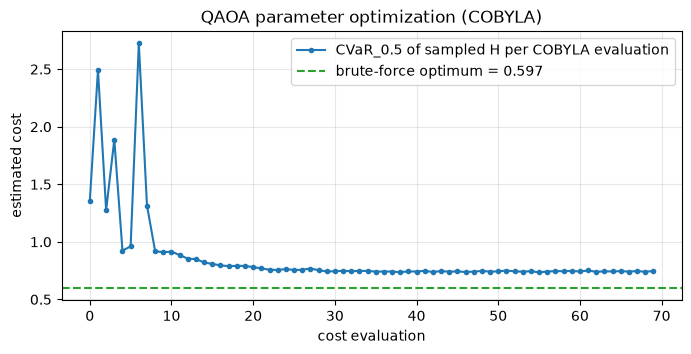

In [7]:
result = run_qaoa(instance, WEIGHTS, CONFIG, qprog=qprog)

plt.figure(figsize=(8, 3.5))
plt.plot(result.objective_values, "o-", ms=3, label=f"CVaR_{CONFIG.quantile} of sampled H per COBYLA evaluation")
plt.axhline(reference.best_cost, color="tab:green", ls="--", label=f"brute-force optimum = {reference.best_cost:.3f}")
plt.xlabel("cost evaluation")
plt.ylabel("estimated cost")
plt.title("QAOA parameter optimization (COBYLA)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Results

Decode the final sample: each bitstring becomes a routing decision, checked classically for one-hot feasibility and
capacity — **QAOA proposes, classical validation selects** (min-cost feasible sampled bitstring). `Φ*` is the exact
Fortz–Thorup normalized congestion cost (**not** the in-Hamiltonian fit). For scale: a uniform-random sampler would put
$\prod_k |P_k| / 2^N = 27/512 \approx 5.3\%$ mass on feasible bitstrings and hit the optimum with $p = 1/512 \approx 0.2\%$.

In [8]:
feasible_mass = feasible_probability(result.samples, instance, result.num_shots)
uniform_mass = 27 / 2**instance.num_qubits
print(f"probability mass on one-hot-feasible bitstrings: {feasible_mass:.1%} "
      f"({feasible_mass / uniform_mass:.1f}x the uniform-sampling baseline of {uniform_mass:.1%})")

top_solutions(result.samples, instance, coeffs, result.num_shots, k=10)

probability mass on one-hot-feasible bitstrings: 49.5% (9.4x the uniform-sampling baseline of 5.3%)


,probability,bits,path[d1],path[d2],path[d3],feasible,cap_violations,max_util,weighted_latency,phi_star,cost
0,0.042480,001010010,2.0,1,1,True,0,0.8,48.0,2.083333,0.596904
1,0.034180,010010001,1.0,1,2,True,0,0.8,46.0,2.069444,0.622222
2,0.032715,000010100,NaN,1,0,False,0,0.6,24.0,0.722222,0.687299
3,0.031738,001100010,2.0,0,1,True,1,1.2,42.0,118.527778,0.756509
4,0.030273,001001010,2.0,2,1,True,0,0.8,48.0,1.972222,0.619210
5,0.029297,001001100,2.0,2,0,True,1,1.4,48.0,326.305556,0.831122
6,0.028809,010010100,1.0,1,0,True,1,1.4,40.0,326.291667,0.753944
7,0.028809,100010010,0.0,1,1,True,1,1.4,40.0,326.416667,0.779969
8,0.028320,000100100,NaN,0,0,False,1,1.2,18.0,117.291667,0.858057
9,0.024902,000001100,NaN,2,0,False,0,0.6,24.0,0.958333,0.754218


In [9]:
best_sol, best_prob = best_feasible_solution(result.samples, instance, coeffs, result.num_shots)

gap = (best_sol.cost - reference.best_cost) / abs(reference.best_cost)
print(f"best sampled feasible solution: {best_sol.chosen}  (sampled with p = {best_prob:.1%})")
print(f"  cost = {best_sol.cost:.4f}  (brute-force optimum {reference.best_cost:.4f}, gap {gap:.1%})")
print(f"  matches brute-force optimum: {best_sol.chosen == reference.best_assignment}")
print(f"  max utilization  = {best_sol.max_utilization:.2f}")
print(f"  capacity violations = {best_sol.capacity_violations}")
print(f"  latency (total / bandwidth-weighted) = {best_sol.total_latency:g} / {best_sol.weighted_latency:g}")
print(f"  Φ = {best_sol.phi_total:.2f},  Φ* = {best_sol.phi_star:.2f} "
      f"(congested if ≥ {CONGESTION_THRESHOLD_PHI_STAR:.2f})")

pd.DataFrame([k.__dict__ for k in best_sol.link_kpis])

best sampled feasible solution: {'d1': 2, 'd2': 1, 'd3': 1}  (sampled with p = 4.2%)
  cost = 0.5969  (brute-force optimum 0.5969, gap 0.0%)
  matches brute-force optimum: True
  max utilization  = 0.80
  capacity violations = 0
  latency (total / bandwidth-weighted) = 14 / 48
  Φ = 50.00,  Φ* = 2.08 (congested if ≥ 10.67)


,link,load,utilization,over_capacity
0,"(A, B)",0.0,0.0,False
1,"(B, D)",3.0,0.6,False
2,"(A, C)",7.0,0.7,False
3,"(C, D)",4.0,0.4,False
4,"(B, C)",0.0,0.0,False
5,"(D, E)",3.0,0.3,False
6,"(D, F)",4.0,0.8,False
7,"(E, F)",3.0,0.3,False
8,"(C, E)",3.0,0.3,False


Two views of the selected routing (`routing_qaoa.viz`): the chosen candidate path per demand, and each link
colored by utilization $u_e = \mathrm{load}_e / c_e$ — over-capacity links ($u_e > 1$) are drawn dashed, and the
color scale saturates at $\max(1, \max_e u_e)$ so 100% is always the same deep red.

In [ ]:
plot_routing(instance, best_sol.chosen, pos=POS, title="QAOA-selected routing (best sampled feasible solution)")
plt.show()

plot_link_utilization(instance, best_sol, pos=POS)
plt.show()

### Did QAOA actually do anything?

The KPI table says the sampled routing is optimal, but that alone does not prove the *quantum* part earned its keep —
a uniform sampler also stumbles onto the optimum eventually. These two figures are the evidence.

**Energy landscape.** Every one of the $2^N = 512$ states, plotted at its cost against how often QAOA sampled it.
Feasible (one-hot) states are highlighted; the dotted line is the uniform baseline $1/512$. The claim to look for:
mass concentrated to the *left*, on low-cost feasible states, and suppressed on the expensive right tail.

**Before/after distribution.** The same sample, compared against a sample taken at the un-optimized initial
parameters (`sample_initial=True`). COBYLA's job is to drag that distribution toward the optimum, and the shift
between the two histograms is exactly what the optimizer bought. Unlike the landscape, this one never enumerates the
state space, so it still works at 28 qubits on the real AT&T instance.

In [ ]:
plot_energy_landscape(
    instance,
    coeffs,
    samples=result.samples,
    num_shots=result.num_shots,
    reference_cost=reference.best_cost,
)
plt.show()

sample_sets = {"optimized params": result.samples}
if result.initial_samples is not None:
    sample_sets = {"initial params": result.initial_samples, **sample_sets}

plot_sampled_cost_distribution(
    sample_sets,
    instance,
    coeffs,
    result.num_shots,
    reference_cost=reference.best_cost,
)
plt.show()

## Discussion & next steps

**Scaling.** Qubits = total candidate paths $N = \sum_k |P_k|$ — with $K$ paths per demand that is $K \cdot (\#\text{demands})$,
*independent of network size*. The edge-based formulation in Classiq's telecom notebook needs $\#\text{demands} \times \#\text{links}$
qubits; classical path pre-enumeration is what buys the reduction (the hybrid split suggested by the challenge).

**Knobs.** `QuboWeights(lambda_onehot, lambda_cong, lambda_switch, cost_scale, congestion_profile)` and
`QaoaConfig(num_layers, num_shots, max_iterations)`. Route-change minimization (challenge KPI) is one flag away:

```python
# penalize deviating from the currently deployed routing:
# run_qaoa(instance, QuboWeights(lambda_switch=0.5, congestion_profile="fortz-thorup-fit", cost_scale=0.1),
#          CONFIG, current_routing={"d1": 0, "d2": 0, "d3": 0})
```

**Next (pipeline steps 2 & 5).** Real K-shortest-path generation with latency/policy filtering; a classical MILP baseline
(`scipy.optimize.milp`, as in the telecom notebook) and comparison against the Fortz–Thorup LP optimum $\Phi^\*_{OPT}$;
KPI report per the challenge: congested-link relief, average latency, demand satisfaction, route changes, zero violations.